In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import joblib


In [11]:
df = pd.read_csv("P:/Dlithe/Project/Dataset/calories.csv")
df = df.drop("User_ID", axis=1)  
df["Gender"] = df["Gender"].map({       # Gender from string to int
    "male": 1,
    "female": 0
})

In [12]:
X = df[
    [
        "Gender",
        "Age",
        "Height",
        "Weight",
        "Duration",
        "Heart_Rate",
        "Body_Temp"
    ]
]
y = df["Calories"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Predicted Calories: [170.94 192.52  53.26 ... 120.21  19.69 214.55]
--------------------Random Forest Regression--------------------
R2 Score: 0.9982158297720679
Mean Absolute Error: 1.7173133333333332
Root Mean Squared Error : 2.6833820078401063


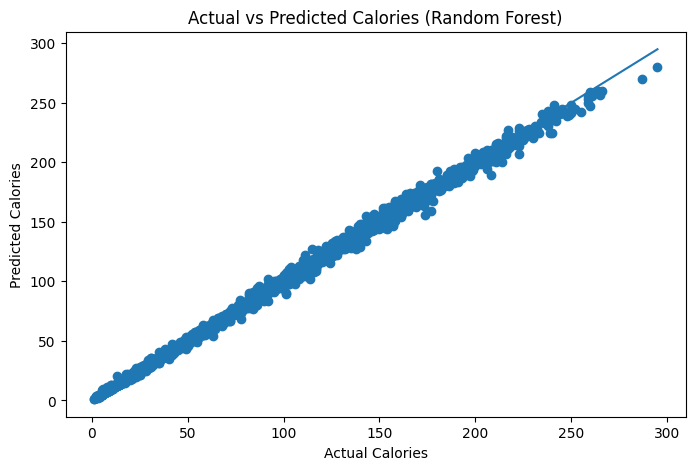

In [13]:
#-------------------------------RANDOM FOREST REGRESSOR--------------------------#
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

prediction = model_rf.predict(X_test)


print("Predicted Calories:", prediction)

print("--------------------Random Forest Regression--------------------")
r2_rf = r2_score(y_test, prediction)
print("R2 Score:", r2_rf)
mae_rf = mean_absolute_error(y_test, prediction)
print("Mean Absolute Error:", mae_rf)
rmse_rf = root_mean_squared_error(y_test, prediction)
print("Root Mean Squared Error :", rmse_rf)

plt.figure(figsize=(8,5))

plt.scatter(y_test, prediction)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories (Random Forest)")

plt.show()

In [14]:
# -----------------------------LINEAR REGRESSOR----------------------------------#.

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("\n-----------------Linear Regression-----------------")
r2_lr = r2_score(y_test, lr_predictions)
print("R2 Score:", r2_lr)
mae_lr = mean_absolute_error(y_test, lr_predictions)
print("Mean Absolute Error:", mae_lr)
rmse_lr = root_mean_squared_error(y_test, lr_predictions)
print("Root Mean Squared Error :", rmse_lr)



-----------------Linear Regression-----------------
R2 Score: 0.9672937151257295
Mean Absolute Error: 8.44151355384971
Root Mean Squared Error : 11.488940149152882


In [15]:
#----------------------------DECISION TREE REGRESSOR---------------------------#


dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print("\n-----------------Decision Tree-----------------")
r2_dt = r2_score(y_test, dt_predictions)
print("R2 Score:", r2_dt)
mae_dt = mean_absolute_error(y_test, dt_predictions)
print("Mean Absolute Error:", mae_dt)
rmse_dt = root_mean_squared_error(y_test, dt_predictions)
print("Root Mean Squared Error :", rmse_dt)




-----------------Decision Tree-----------------
R2 Score: 0.9929452912784914
Mean Absolute Error: 3.437333333333333
Root Mean Squared Error : 5.335853571204267


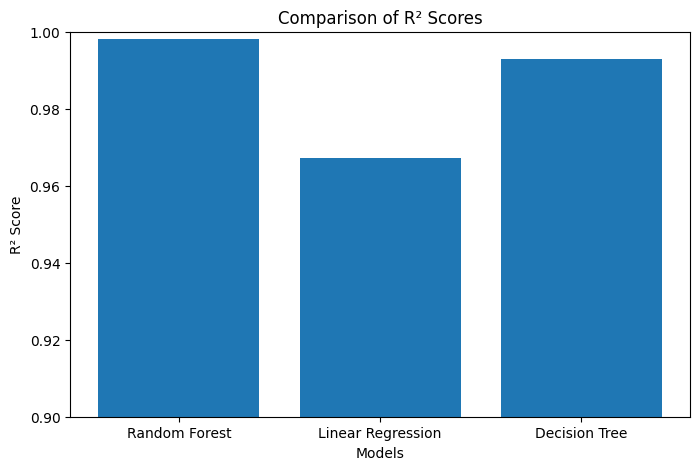

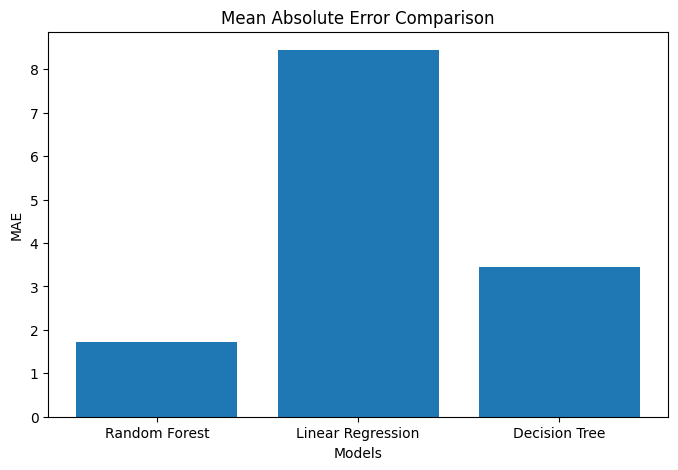

In [16]:
models = ["Random Forest", "Linear Regression", "Decision Tree"]

#COMPARISON OF R2 SCORES
r2_scores = [r2_rf,r2_lr,r2_dt]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Comparison of R² Scores")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.ylim(0.9, 1.0)

plt.show()
#COMPARISON OF MAE SCORES
mae_scores = [mae_rf,mae_lr,mae_dt]

plt.figure(figsize=(8,5))
plt.bar(models, mae_scores)

plt.title("Mean Absolute Error Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")

plt.show()

In [18]:

joblib.dump(model_rf, "P:/Dlithe/Project/ML_model/calorie_model.pkl")

['P:/Dlithe/Project/ML_model/calorie_model.pkl']